In [40]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.spatial.transform import Rotation
from scipy.signal import find_peaks
from pathlib import Path

### Get the data

In [6]:
def load_marker_data(file_path: str | Path, tracked_points: None | str | list[str]) -> dict[str, np.ndarray]:
    # Load the raw marker data
    data = pd.read_csv(file_path, header=0, sep="\t")

    # Select columns that contain marker position data
    data = data[[c for c in data.columns if not c.split("_")[-1] in ["n/a", "err"]]]

    # Get all available tracked points
    all_tracked_points = ["_".join(c.split("_")[:-2]) for c in data.columns]
    if not tracked_points:
        tracked_points = all_tracked_points
    elif isinstance(tracked_points, str):
        tracked_points = [tracked_points]
    else:
        pass  # nothing to change

    return {
        tracked_point: data.loc[:, [f"{tracked_point}_POS_{x}" for x in "xyz"]].to_numpy()
        for tracked_point in tracked_points
    }

In [10]:
# Set the path
RAW_DATA_PATH = Path("/home/robbin/Datasets/Keep Control/rawdata")

# Choose a subject and task
sub_id = "pp002"
task_name = "treadmill"
run_name = None

# Choose markers
tracked_points = [f"{lr}_{mrk}" for lr in "lr" for mrk in ["asis", "psis", "heel", "toe"]]


file_name = f"sub-{sub_id}_task-{task_name}_tracksys-omc_motion.tsv"

markers = load_marker_data(
    file_path=RAW_DATA_PATH / f"sub-{sub_id}" / "motion" / file_name,
    tracked_points=tracked_points
)


### Preprocess the data

We will compute virtual markers to represent the mid posterior superior iliac spine (`mid_psis`) and mid anterior superior iliac spine (`mid_asis`). Thoese virtual markers can then be used to estimate the heading, namely the vector pointing from the `mid_psis` to the `mid_asis`. We take the average heading over the entire trial, and rotate all marker trajectories in the horizontal plane such that a forward swing of either leg is associated with a displacement in the +$X$-direction. 

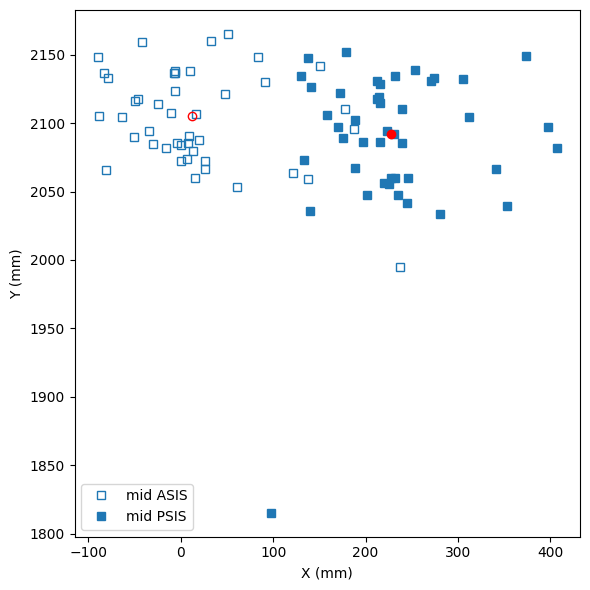

In [30]:
for mrk in ["asis", "psis"]:
    markers[f"mid_{mrk}"] = (markers[f"l_{mrk}"] + markers[f"r_{mrk}"]) / 2.0

# Show the virtual markers on the horizontal plane
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(markers["mid_asis"][::1000, 0], markers["mid_asis"][::1000, 1], "s", mfc="none", mec="tab:blue", label="mid ASIS")
ax.plot(markers["mid_psis"][::1000, 0], markers["mid_psis"][::1000, 1], "s", mfc="tab:blue", mec="tab:blue", label="mid PSIS")
ax.plot(np.nanmean(markers["mid_asis"][:, 0]), np.nanmean(markers["mid_asis"][:, 1]), "o", mfc="none", mec="red")
ax.plot(np.nanmean(markers["mid_psis"][:, 0]), np.nanmean(markers["mid_psis"][:, 1]), "o", mfc="red", mec="red")
ax.set_xlabel("X (mm)")
ax.set_ylabel("Y (mm)")
ax.legend(loc="best")
ax.set_aspect("auto")
plt.tight_layout()
plt.show()

In [28]:
# Compute the heading vector as the difference between the two virtual midpoints
d = np.nanmean(markers["mid_asis"], axis=0) - np.nanmean(markers["mid_psis"], axis=0)

# Heading angle
theta = np.arctan2(d[1], d[0])
print(f"Estimated heading angle: {theta:.2f} rad ({np.rad2deg(theta):.1f} deg)")

Estimated heading angle: 3.08 rad (176.5 deg)


To align the marker data with a global $XYZ$-frame, we define the average marker position of the `mid_psis` as the origin. Then, for each marker we first subtract the origin from the marker position, and then apply a rotation about the $Z$-axis of $\theta$.

In [53]:
# Define the origin
origin = np.nanmean(markers["mid_psis"], axis=0, keepdims=True)  # shape: (1, 3)

# Rotate the markers
R = Rotation.from_rotvec(theta * np.array([0., 0., 1.]), degrees=False)
rotated_markers = dict()
for mrk, vals in markers.items():
    vals -= origin
    rot_vals = R.apply(vals)
    rotated_markers[mrk] = rot_vals


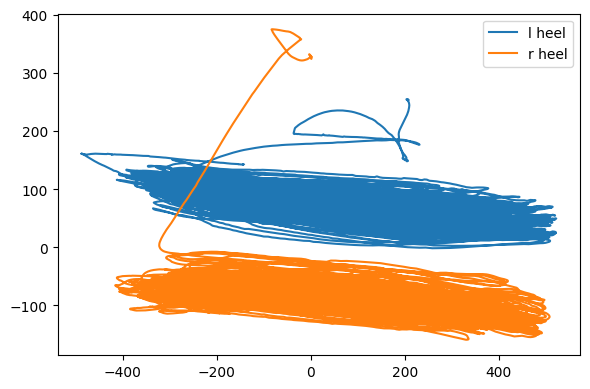

In [54]:
fig, ax = plt.subplots(figsize=(6, 4))
for side in ["l", "r"]:
    ax.plot(rotated_markers[f"{side}_heel"][:, 0], rotated_markers[f"{side}_heel"][:, 1], label=f"{side} heel")
ax.legend(loc="best")
plt.tight_layout()
plt.show()

### Detect gait events

We detect initial contacts as local maxima of the heel positions relative to the pelvis markers. Similarly, we detect final contacts as local minima of the toe markers relative to the pelvis markers.

In [41]:
events = dict()
for side in ["l", "r"]:
    idxs, _ = find_peaks(rotated_markers[f"{side}_heel"][:, 0] - rotated_markers["mid_psis"][:, 0], height=25., distance=50)
    events[f"IC{side.upper()}"] = idxs

    idxs, _ = find_peaks(-(rotated_markers[f"{side}_toe"][:, 0] - rotated_markers["mid_psis"][:, 0]), height=25., distance=50)
    events[f"FC{side.upper()}"] = idxs

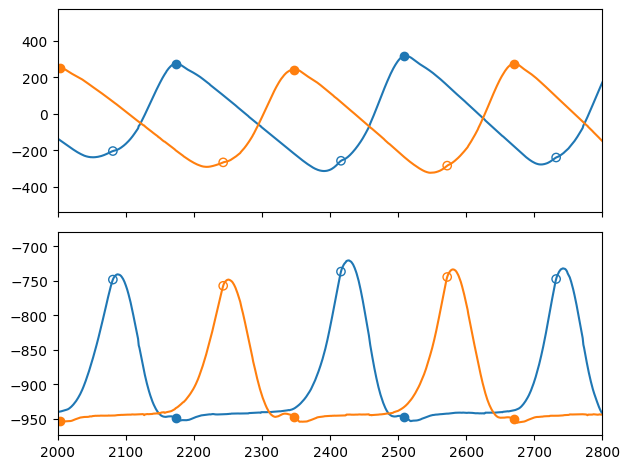

In [63]:
fig, axs = plt.subplots(2, 1, sharex=True)
for mrk in ["l_heel", "r_heel"]:
    axs[0].plot(rotated_markers[mrk][:, 0])
    axs[0].scatter(events[f"IC{mrk[0].upper()}"], rotated_markers[mrk][events[f"IC{mrk[0].upper()}"], 0])
    axs[0].scatter(events[f"FC{mrk[0].upper()}"], rotated_markers[mrk][events[f"FC{mrk[0].upper()}"], 0], ec="tab:blue" if mrk == "l_heel" else "tab:orange", fc="none")
    axs[1].plot(rotated_markers[mrk][:, 2])
    axs[1].scatter(events[f"IC{mrk[0].upper()}"], rotated_markers[mrk][events[f"IC{mrk[0].upper()}"], 2])
    axs[1].scatter(events[f"FC{mrk[0].upper()}"], rotated_markers[mrk][events[f"FC{mrk[0].upper()}"], 2], ec="tab:blue" if mrk == "l_heel" else "tab:orange", fc="none")
for ax in axs:
    ax.set_xlim((2_000, 2_800))
plt.tight_layout()
plt.show()

Now, let us compute the relative position of the feet at heel strike of one side with respect to the contralateral side. The contralateral side functions as stance leg at the point in time.

In [50]:
# For each left heel strike
for il in events["ICL"]:
    # Find the next right heel strike
    f = np.argwhere(events["ICR"] > il)[:, 0]
    if len(f) > 0:
        ir = events["ICR"][f[0]]
    
    # Compute the distance vector
    d = rotated_markers["r_heel"][ir,] - rotated_markers["l_heel"][il,]
    print(d)

[  92.49562042 -211.45620027   -4.59137338]
[   3.24276726 -231.91337451   -3.57327207]
[  -5.78091743 -214.77555917    2.09109021]
[ -13.77654079 -221.26883606   -3.71248143]
[ -34.78965599 -205.30869907   -3.25845619]
[ -30.97023168 -229.11215888   -7.80346813]
[ -14.00739927 -196.61196869   -1.14817676]
[  10.08503533 -212.40030863    1.10571846]
[  27.56692026 -196.71605403    5.28909101]
[ -23.5333921  -200.35844045   -9.18910105]
[ -11.11120926 -190.86982666   -6.96222675]
[   1.67725673 -218.50906467   -1.89002015]
[   2.90914543 -169.35927856    7.04640885]
[  27.95613398 -186.3768642     2.47335758]
[  -5.96139509 -202.90453196   -2.19141319]
[  12.56485461 -196.15154191   -1.0363217 ]
[  -1.4520478  -203.93662472    0.43768276]
[ -24.6249758  -172.74054065   -1.68421145]
[   5.40553441 -193.50600205    0.50335411]
[   6.67175515 -184.28774767    1.42112505]
[   5.26668895 -178.80797085    0.55937267]
[  23.38111594 -185.53429386    3.20859513]
[  -3.69541646 -202.11381888    

In [49]:
d

array([ -78.0214435 , -302.29087292,   -4.70459044])